In [7]:
import os
from google.colab import drive
drive.mount('/content/drive')
os.chdir("/content/drive/MyDrive/UChicago/TTIC31040/homography")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

### 2. Data Visualization

In [9]:
data = pd.read_csv("./homography_results.csv")

# normalize reprojection error
diag_map = {}

for img_name in data['img'].unique():
  path = f"./hpatches-sequences-release/{img_name}/1.ppm"
  img = cv2.imread(path)
  h, w = img.shape[:2]
  diag_map[img_name] = np.sqrt(h**2 + w**2)

data['diag'] = data['img'].map(diag_map)
data['re_error'] = data['reprojection_error'] / data['diag']

# inliers ratio
data['inliner_ratio'] = data['num_inliers']/data['num_matches']

In [14]:
# Get the row with maximum differnece btw center and border (for plotting)
df_cb = data[data["region"].isin(["center", "border"])]
pivot = df_cb.pivot_table(
    index=["img", "distortion"],
    columns="region",
    values="reprojection_error"
).reset_index()

pivot["error_diff"] = (pivot["center"] - pivot["border"]).abs()
result = pivot.loc[pivot["error_diff"].idxmin()]

print(result)

region
img            v_feast
distortion       large
border        1.192794
center        1.195836
error_diff    0.003042
Name: 53, dtype: object


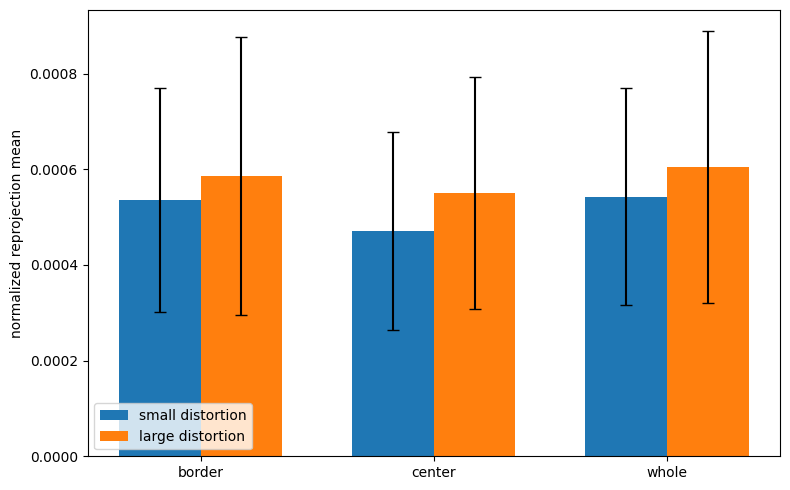

In [11]:
# re_erro mean: bar plots by large & small distortion, error bar by std, x: keypoints region
# inliers ratio: bar plots by large & small distortion, error bar by std, x: keypoints region
regions = ['border','center','whole']
x = np.arange(len(regions))
width = 0.35

small_stats = (data[data['distortion']=='small'].groupby('region')['re_error'].agg(['mean','std'])
              .reindex(regions))

large_stats = (data[data['distortion']=='large'].groupby('region')['re_error'].agg(['mean','std'])
              .reindex(regions))

fig, ax = plt.subplots(figsize=(8,5))

# bars
ax.bar(x - width/2, small_stats['mean'], width,
        yerr=small_stats['std'], capsize=4, label='small distortion')

ax.bar(x + width/2,large_stats['mean'], width,
        yerr=large_stats['std'], capsize=4, label='large distortion')

ax.set_xticks(x)
ax.set_xticklabels(regions)
ax.set_ylabel("normalized reprojection mean")
ax.legend(loc='lower left')

plt.tight_layout()
plt.show()

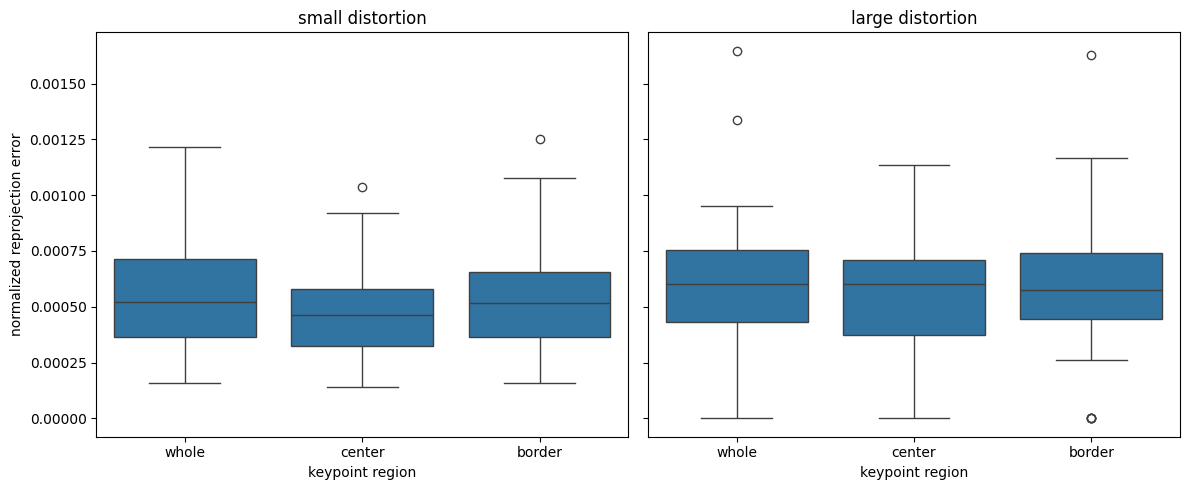

In [12]:
fig, axes = plt.subplots(1,2, figsize=(12,5), sharey=True)

for i, distortion in enumerate(['small','large']):

    subset = data[data['distortion'] == distortion]

    sns.boxplot(
        data=subset,
        x='region',
        y='re_error',
        ax=axes[i]
    )

    axes[i].set_title(f"{distortion} distortion")
    axes[i].set_xlabel("keypoint region")
    axes[i].set_ylabel("normalized reprojection error")

plt.tight_layout()
plt.show()

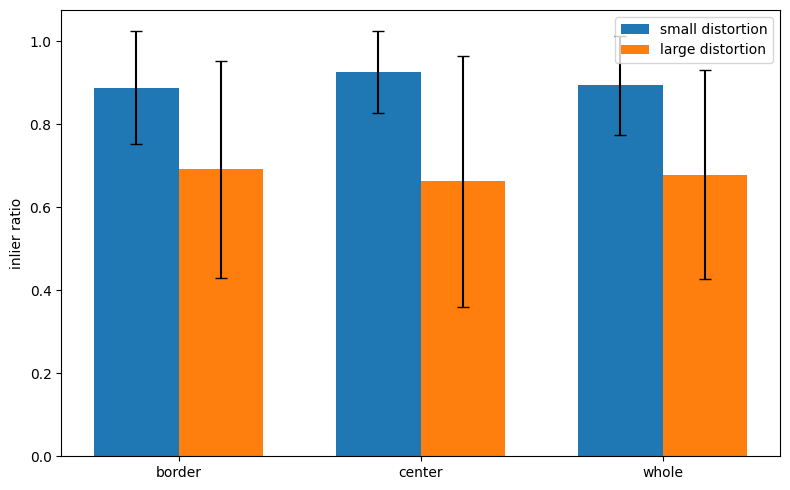

In [13]:
# inliers ratio: bar plots by large & small distortion, error bar by std, x: keypoints region
regions = ['border','center','whole']
x = np.arange(len(regions))
width = 0.35

small_stats = (data[data['distortion']=='small'].groupby('region')['inliner_ratio'].agg(['mean','std'])
              .reindex(regions))

large_stats = (data[data['distortion']=='large'].groupby('region')['inliner_ratio'].agg(['mean','std'])
              .reindex(regions))

fig, ax = plt.subplots(figsize=(8,5))

# bars
ax.bar(x - width/2, small_stats['mean'], width,
        yerr=small_stats['std'], capsize=4, label='small distortion')

ax.bar(x + width/2,large_stats['mean'], width,
        yerr=large_stats['std'], capsize=4, label='large distortion')

ax.set_xticks(x)
ax.set_xticklabels(regions)
ax.set_ylabel("inlier ratio")
ax.legend()

plt.tight_layout()
plt.show()